In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [4]:
import torch
print(torch.__version__, torch.cuda.is_available())
import numpy as np
import matplotlib.pyplot as plt
from models import FNO, device, dtype

from earth_mars_transfer_helpers import *
from earth_mars_solver_functions import *

rng = np.random.default_rng(42)
base = calendar_to_epoch(2026, 1, 1)
deps_raw = base + rng.uniform(0, 20 * 86400, size=15)
tofs_raw = np.ones(15) * 200 

# deps, tofs, angles = filter_transfers(deps_raw, tofs_raw, min_angle=30.0)
print(f"Kept {len(deps_raw)} / 15")

soi, lamb, pert, corr, arc_lens = generate_dataset(
    deps_raw, tofs_raw, number_of_arcs=1000
)

2.6.0+cu124 True
Kept 15 / 15
  [1/15]  tof=200d  Dv=34.0 m/s  ~0.9m left
  [2/15]  tof=200d  Dv=33.8 m/s  ~0.8m left
  [3/15]  tof=200d  Dv=34.1 m/s  ~0.7m left
  [4/15]  tof=200d  Dv=34.1 m/s  ~0.7m left
  [5/15]  tof=200d  Dv=33.5 m/s  ~0.6m left
  [6/15]  tof=200d  Dv=34.3 m/s  ~0.6m left
  [7/15]  tof=200d  Dv=34.0 m/s  ~0.5m left
  [8/15]  tof=200d  Dv=34.0 m/s  ~0.4m left
  [9/15]  tof=200d  Dv=33.5 m/s  ~0.4m left
  [10/15]  tof=200d  Dv=33.8 m/s  ~0.3m left
  [11/15]  tof=200d  Dv=33.7 m/s  ~0.2m left
  [12/15]  tof=200d  Dv=34.2 m/s  ~0.2m left
  [13/15]  tof=200d  Dv=34.1 m/s  ~0.1m left
  [14/15]  tof=200d  Dv=34.1 m/s  ~0.1m left
  [15/15]  tof=200d  Dv=33.8 m/s  ~0.0m left


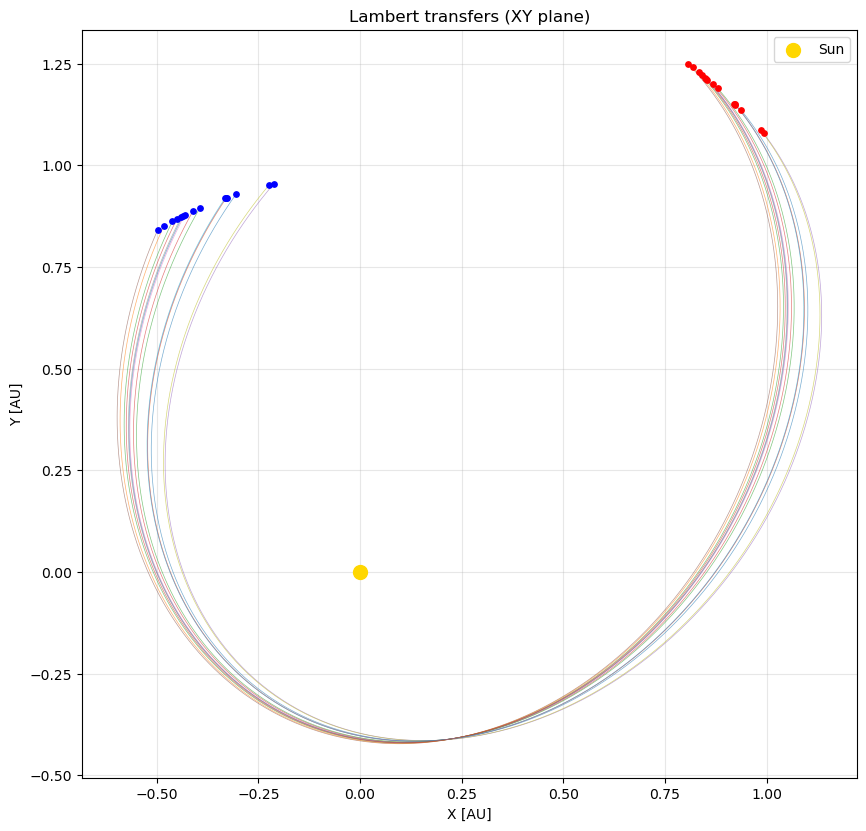

In [5]:
def plot_transfers(lamb, soi, sample_indices=None, title="Lambert transfers (XY plane)"):
    """
    lamb: (M, N+1, 6)
    soi:  (M, 2)
    sample_indices: which samples to plot, default all
    """
    AU = 1.496e11
    if sample_indices is None:
        sample_indices = range(lamb.shape[0])
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(0, 0, s=100, color="gold", zorder=10, label="Sun")
    
    for i in sample_indices:
        x = lamb[i, :, 0] / AU
        y = lamb[i, :, 1] / AU
        ax.plot(x, y, linewidth=0.5, alpha=0.6)
        ax.scatter(x[0], y[0], s=15, color="blue", zorder=5)   # departure
        ax.scatter(x[-1], y[-1], s=15, color="red", zorder=5)   # arrival
    
    ax.set_xlabel("X [AU]")
    ax.set_ylabel("Y [AU]")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.legend()
    plt.show()
plot_transfers(lamb, soi)

In [ ]:
X_mean, X_std = d["X_mean"], d["X_std"]
Y_mean, Y_std = d["Y_mean"], d["Y_std"]
M, N = lamb.shape[0], lamb.shape[1] - 1

X_raw = lamb[:, :-1, :]
Y_raw = corr / arc_lens[:, None, None]